# Canonical Correlation Analysis: Learning Behavior and Academic Performance

This Notebook uses Canonical Correlation Analysis (CCA) to examine the relationship between **a set of learning-behavior variables** and **a set of academic-performance variables**.

# 正準相関分析：学習行動と学業成績の関係

このNotebookでは、**学習行動を表す複数の変数群**と**学業成績を表す複数の変数群**の関係を、正準相関分析（Canonical Correlation Analysis: CCA）で分析します。

## 1. Learning Objectives / 学習目標

- Understand why CCA analyzes relationships between two variable sets
- Distinguish CCA from ordinary correlation and multiple regression
- Understand canonical variates and canonical correlations
- Standardize two sets of variables and fit CCA
- Interpret canonical correlations
- Examine canonical loadings
- Visualize relationships in canonical space
- Understand limitations of CCA

- 正準相関分析が「2つの変数群」の関係を分析する手法であることを理解する
- 単相関・重回帰分析との違いを理解する
- 正準変量と正準相関係数を理解する
- 2つの変数群を標準化してCCAを実行する
- 正準相関係数を解釈する
- 正準負荷量を確認する
- 正準空間を可視化する
- CCAの注意点を理解する

## 2. Use Case / ユースケース

A university wants to understand how students' overall learning behavior is related to their overall academic performance.

The learning-behavior set contains:

- weekly study hours
- attendance rate
- assignment completion rate
- weekly practice sessions

The academic-performance set contains:

- mathematics score
- science score
- writing score
- overall examination score

Instead of examining every pair of correlations separately, CCA summarizes the strongest relationships between the two sets.

ある大学では、「学生の学習行動全体」と「学業成績全体」がどのように関係しているかを把握したいと考えています。

学習行動側には勉強時間・出席率・課題提出率など複数の変数があり、成績側にも数学・科学・作文・総合試験など複数の変数があります。

個々の相関係数をバラバラに見るのではなく、2つの変数群の関係をまとめて捉えるために正準相関分析を使用します。

## 3. What Is Canonical Correlation Analysis? / 正準相関分析とは

Suppose we have two variable sets:

**X set**

`X1, X2, ..., Xp`

**Y set**

`Y1, Y2, ..., Yq`

CCA creates linear combinations:

`U = a1X1 + a2X2 + ... + apXp`

`V = b1Y1 + b2Y2 + ... + bqYq`

and chooses the coefficients so that the correlation between `U` and `V` is as large as possible.

`U` and `V` are called **canonical variates**, and their correlation is the **canonical correlation**.

2つの変数群XとYから、それぞれの変数を重み付きで組み合わせた新しい変数UとVを作ります。

そして、**UとVの相関が最大になるような重みを求める**のが正準相関分析です。

UとVを**正準変量**、その相関係数を**正準相関係数**と呼びます。

## 4. CCA Compared with Other Methods / 他の分析手法との違い

| Method | Main Question |
|---|---|
| Correlation | How strongly are two individual variables related? |
| Multiple Regression | How does one target variable relate to multiple explanatory variables? |
| PCA | How can one variable set be summarized with fewer dimensions? |
| CCA | How strongly are two multivariate variable sets related? |

| 手法 | 主な問い |
|---|---|
| 相関分析 | 2つの個別変数はどれくらい関連しているか |
| 重回帰分析 | 1つの目的変数を複数の説明変数でどう説明するか |
| 主成分分析 | 1つの変数群を少数の軸にどう要約するか |
| 正準相関分析 | 2つの多変量な変数群はどのように関連しているか |

## 5. Import Libraries / ライブラリの読み込み

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)

## 6. Load the Dataset / データの読み込み

In [2]:
candidate_paths = [
    Path("../data/student_learning_performance.csv"),
    Path("07_canonical_correlation/data/student_learning_performance.csv"),
    Path("data/student_learning_performance.csv"),
]

data_path = next((p for p in candidate_paths if p.exists()), None)

if data_path is None:
    raise FileNotFoundError("student_learning_performance.csv was not found.")

df = pd.read_csv(data_path)
df.head()

,student_id,study_hours_week,attendance_rate,assignment_completion_rate,practice_sessions_week,math_score,science_score,writing_score,exam_score
0,S001,10.3,72.9,68.7,2.1,66.1,61.9,69.3,60.1
1,S002,11.4,75.2,90.1,4.2,59.8,59.6,69.8,62.4
2,S003,15.2,82.4,81.7,6.9,80.6,77.5,68.8,75.4
3,S004,19.3,82.7,94.0,9.5,90.0,89.5,78.3,89.0
4,S005,8.9,75.7,76.6,4.4,55.9,61.1,50.1,62.5


## 7. Understand the Dataset / データの理解

In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.info()

Rows: 240
Columns: 9
<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  240 non-null    str    
 1   study_hours_week            240 non-null    float64
 2   attendance_rate             240 non-null    float64
 3   assignment_completion_rate  240 non-null    float64
 4   practice_sessions_week      240 non-null    float64
 5   math_score                  240 non-null    float64
 6   science_score               240 non-null    float64
 7   writing_score               240 non-null    float64
 8   exam_score                  240 non-null    float64
dtypes: float64(8), str(1)
memory usage: 17.0 KB


In [4]:
df.isna().sum()

student_id                    0
study_hours_week              0
attendance_rate               0
assignment_completion_rate    0
practice_sessions_week        0
math_score                    0
science_score                 0
writing_score                 0
exam_score                    0
dtype: int64

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
study_hours_week,240.0,12.056250,4.025240,2.0,9.100,11.90,14.600,22.5
attendance_rate,240.0,82.142500,8.111097,59.5,76.175,82.30,87.900,100.0
assignment_completion_rate,240.0,80.187917,9.080803,56.9,73.975,79.40,86.750,100.0
practice_sessions_week,240.0,4.927917,1.872531,1.0,3.700,4.90,6.000,10.0
math_score,240.0,68.505833,9.937018,40.7,61.500,67.55,76.125,100.0
science_score,240.0,70.030417,9.800168,41.5,63.075,69.40,77.000,97.6
writing_score,240.0,71.165000,9.892579,37.0,64.450,70.15,78.500,97.1
exam_score,240.0,68.739167,9.208167,46.5,62.375,68.00,74.000,91.5


## 8. Define the Two Variable Sets / 2つの変数群を定義する

The central idea of CCA is that variables are divided into two conceptually meaningful sets.

CCAの重要なポイントは、分析対象を意味のある2つの変数群に分けることです。

In [6]:
x_features = [
    "study_hours_week",
    "attendance_rate",
    "assignment_completion_rate",
    "practice_sessions_week",
]

y_features = [
    "math_score",
    "science_score",
    "writing_score",
    "exam_score",
]

X = df[x_features].copy()
Y = df[y_features].copy()

print("X set:", x_features)
print("Y set:", y_features)
print("X shape:", X.shape)
print("Y shape:", Y.shape)

X set: ['study_hours_week', 'attendance_rate', 'assignment_completion_rate', 'practice_sessions_week']
Y set: ['math_score', 'science_score', 'writing_score', 'exam_score']
X shape: (240, 4)
Y shape: (240, 4)


## 9. Inspect Ordinary Correlations / 通常の相関を確認する

Before CCA, inspect pairwise correlations between the X and Y variables.

This provides useful background, but many pairwise correlations can become difficult to interpret simultaneously.

CCA addresses this by finding combinations of variables that maximize the relationship between the two sets.

CCAの前に、X群とY群の個々の相関係数を確認します。

ただし、変数数が増えると相関係数の組み合わせも増え、全体像を捉えにくくなります。CCAでは、変数を組み合わせることで2つの変数群の関係を要約します。

In [7]:
cross_corr = df[x_features + y_features].corr().loc[x_features, y_features]
cross_corr.round(3)

,math_score,science_score,writing_score,exam_score
study_hours_week,0.707,0.678,0.603,0.728
attendance_rate,0.634,0.617,0.626,0.678
assignment_completion_rate,0.566,0.517,0.613,0.573
practice_sessions_week,0.672,0.586,0.538,0.644


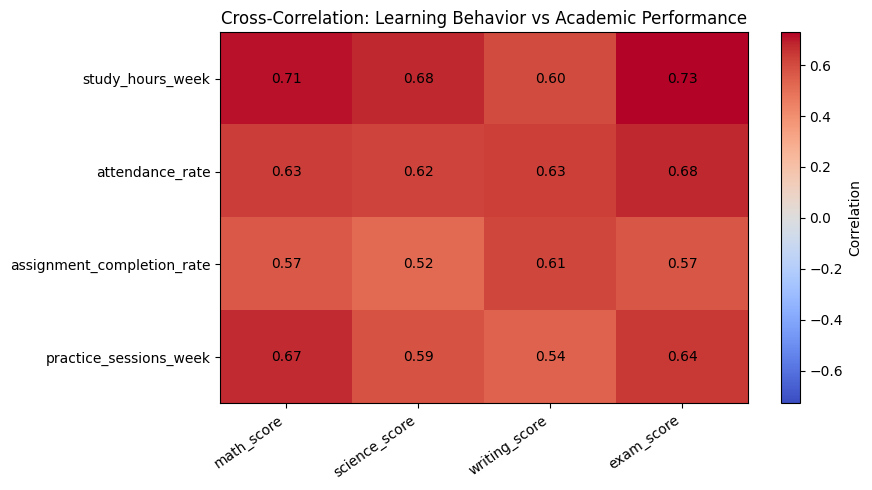

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
limit = np.abs(cross_corr.values).max()

image = ax.imshow(
    cross_corr.values,
    aspect="auto",
    cmap="coolwarm",
    vmin=-limit,
    vmax=limit,
)

ax.set_xticks(range(len(y_features)), labels=y_features, rotation=35, ha="right")
ax.set_yticks(range(len(x_features)), labels=x_features)

for i in range(cross_corr.shape[0]):
    for j in range(cross_corr.shape[1]):
        ax.text(j, i, f"{cross_corr.iloc[i, j]:.2f}", ha="center", va="center")

fig.colorbar(image, ax=ax, label="Correlation")
ax.set_title("Cross-Correlation: Learning Behavior vs Academic Performance")
plt.tight_layout()
plt.show()

## 10. Standardize the Variables / 変数の標準化

The variables use different units such as hours, percentages, sessions, and test scores.

We standardize each variable so that differences in measurement scale do not dominate the analysis.

変数には時間、割合、回数、点数など異なる単位があります。

測定尺度の違いが分析結果を支配しないように、各変数を平均0・標準偏差1に標準化します。

In [9]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_scaled = x_scaler.fit_transform(X)
Y_scaled = y_scaler.fit_transform(Y)

print("X standardized means:", np.round(X_scaled.mean(axis=0), 3))
print("Y standardized means:", np.round(Y_scaled.mean(axis=0), 3))

X standardized means: [-0.  0. -0.  0.]
Y standardized means: [-0. -0. -0. -0.]


## 11. Fit Canonical Correlation Analysis / 正準相関分析を実行する

The number of possible canonical components is at most the smaller number of variables in the two sets.

Here both sets contain four variables, so up to four canonical pairs can be obtained.

正準変量の組の最大数は、2つの変数群のうち変数数が少ない方までです。

今回はX群・Y群ともに4変数なので、最大4組の正準変量を求められます。

In [10]:
n_components = min(len(x_features), len(y_features))

cca = CCA(
    n_components=n_components,
    scale=False,
    max_iter=1000,
)

X_c, Y_c = cca.fit_transform(X_scaled, Y_scaled)

print("X canonical variates shape:", X_c.shape)
print("Y canonical variates shape:", Y_c.shape)

X canonical variates shape: (240, 4)
Y canonical variates shape: (240, 4)


## 12. Canonical Correlations / 正準相関係数

For each canonical pair, calculate the correlation between the X-side canonical variate and the corresponding Y-side canonical variate.

The first pair has the largest possible correlation. Later pairs describe additional relationships after the earlier dimensions have been extracted.

各正準変量ペアについて、X側とY側の相関係数を求めます。

第1正準相関が最も強い関係を表し、第2以降は、それまでの軸とは異なる追加的な関係を表します。

In [11]:
canonical_correlations = [
    np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1]
    for i in range(n_components)
]

canonical_corr_df = pd.DataFrame({
    "canonical_dimension": [f"CV{i+1}" for i in range(n_components)],
    "canonical_correlation": canonical_correlations,
    "squared_canonical_correlation": np.square(canonical_correlations),
})

canonical_corr_df.round(3)

,canonical_dimension,canonical_correlation,squared_canonical_correlation
0,CV1,0.894,0.800
1,CV2,0.244,0.059
2,CV3,0.105,0.011
3,CV4,0.020,0.000


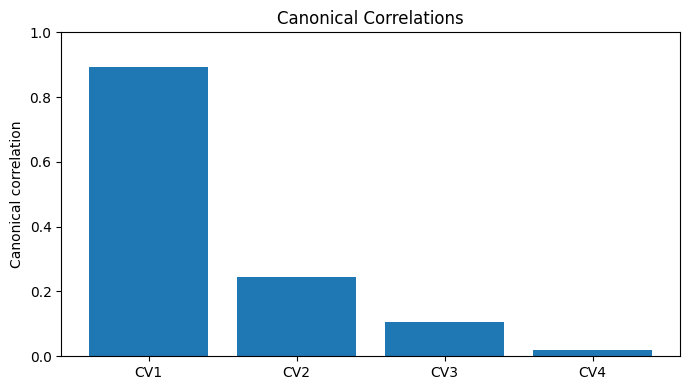

In [12]:
plt.figure(figsize=(7, 4))
plt.bar(
    canonical_corr_df["canonical_dimension"],
    canonical_corr_df["canonical_correlation"],
)
plt.ylim(0, 1)
plt.ylabel("Canonical correlation")
plt.title("Canonical Correlations")
plt.tight_layout()
plt.show()

### Squared Canonical Correlation / 正準相関係数の二乗

The squared canonical correlation represents the proportion of variance shared between a pair of canonical variates.

It should not be interpreted as the percentage of all original-variable variance explained by the other set.

正準相関係数の二乗は、**その正準変量ペア同士が共有する分散の割合**を表します。

「元の変数群全体の何%を説明した」という意味ではない点に注意してください。

## 13. Visualize the First Canonical Pair / 第1正準変量ペアを可視化する

If the first canonical correlation is strong, observations with high values on the X-side canonical variate also tend to have high values on the Y-side canonical variate.

第1正準相関が強ければ、X側の第1正準変量が高い学生ほど、Y側の第1正準変量も高くなる傾向が見られます。

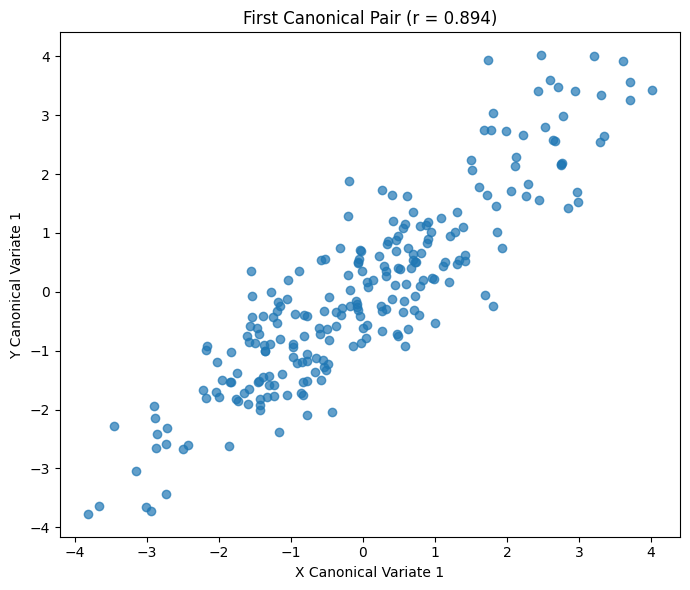

In [13]:
plt.figure(figsize=(7, 6))
plt.scatter(X_c[:, 0], Y_c[:, 0], alpha=0.7)
plt.xlabel("X Canonical Variate 1")
plt.ylabel("Y Canonical Variate 1")
plt.title(
    f"First Canonical Pair (r = {canonical_correlations[0]:.3f})"
)
plt.tight_layout()
plt.show()

## 14. Canonical Loadings / 正準負荷量

Canonical coefficients are the weights used to construct the canonical variates. However, weights can become unstable when original variables are correlated.

For interpretation, it is often useful to calculate **canonical loadings**: correlations between each original variable and its own canonical variate.

正準係数は正準変量を作るための重みですが、元変数同士に相関がある場合には値が不安定になることがあります。

そこで解釈には、**元変数と同じ側の正準変量との相関**である「正準負荷量」を確認すると分かりやすくなります。

In [14]:
def canonical_loadings(original_scaled, canonical_scores, feature_names):
    values = np.empty((original_scaled.shape[1], canonical_scores.shape[1]))
    for i in range(original_scaled.shape[1]):
        for j in range(canonical_scores.shape[1]):
            values[i, j] = np.corrcoef(
                original_scaled[:, i],
                canonical_scores[:, j],
            )[0, 1]

    return pd.DataFrame(
        values,
        index=feature_names,
        columns=[f"CV{j+1}" for j in range(canonical_scores.shape[1])],
    )

x_loadings = canonical_loadings(X_scaled, X_c, x_features)
y_loadings = canonical_loadings(Y_scaled, Y_c, y_features)

print("X-side canonical loadings")
display(x_loadings.round(3))

print("Y-side canonical loadings")
display(y_loadings.round(3))

X-side canonical loadings


,CV1,CV2,CV3,CV4
study_hours_week,0.914,-0.177,-0.180,-0.317
attendance_rate,0.859,0.245,-0.279,0.352
assignment_completion_rate,0.764,0.560,0.230,-0.221
practice_sessions_week,0.826,-0.225,0.489,0.166


Y-side canonical loadings


,CV1,CV2,CV3,CV4
math_score,0.861,-0.247,0.438,-0.077
science_score,0.807,-0.195,-0.396,-0.393
writing_score,0.770,0.619,0.056,-0.141
exam_score,0.879,-0.147,-0.287,0.351


## 15. Interpret the First Canonical Dimension / 第1正準次元を解釈する

Focus first on variables with large absolute loadings on CV1.

The sign of an entire canonical dimension is arbitrary: multiplying both canonical variates by -1 does not change their correlation. Therefore, interpretation should focus mainly on **magnitude and relative direction**, not on whether the overall dimension happens to be positive or negative.

まず、CV1で絶対値の大きい負荷量を持つ変数に注目します。

なお、正準変量の符号そのものは任意です。X側とY側を同時に-1倍しても相関は変わりません。そのため、単純なプラス・マイナスよりも、**負荷量の大きさと変数同士の相対的な方向**を見ることが重要です。

In [15]:
first_dimension = pd.concat(
    [
        x_loadings["CV1"].rename("X_loading_CV1"),
        y_loadings["CV1"].rename("Y_loading_CV1"),
    ],
    axis=0,
)

first_dimension.reindex(
    first_dimension.abs().sort_values(ascending=False).index
).round(3)

study_hours_week              0.914
exam_score                    0.879
math_score                    0.861
attendance_rate               0.859
practice_sessions_week        0.826
science_score                 0.807
writing_score                 0.770
assignment_completion_rate    0.764
dtype: float64

## 16. Loading Heatmaps / 正準負荷量のヒートマップ

The heatmaps show which original variables are strongly associated with each canonical dimension.

ヒートマップを使うと、各正準次元と強く関連している元変数を視覚的に確認できます。

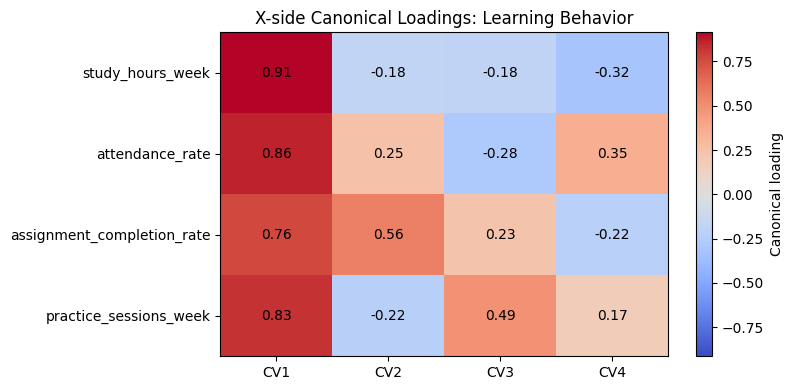

In [16]:
def plot_loading_heatmap(loadings, title):
    fig, ax = plt.subplots(figsize=(8, 4))
    limit = np.abs(loadings.values).max()

    image = ax.imshow(
        loadings.values,
        aspect="auto",
        cmap="coolwarm",
        vmin=-limit,
        vmax=limit,
    )

    ax.set_xticks(range(loadings.shape[1]), labels=loadings.columns)
    ax.set_yticks(range(loadings.shape[0]), labels=loadings.index)

    for i in range(loadings.shape[0]):
        for j in range(loadings.shape[1]):
            ax.text(
                j,
                i,
                f"{loadings.iloc[i, j]:.2f}",
                ha="center",
                va="center",
            )

    fig.colorbar(image, ax=ax, label="Canonical loading")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_loading_heatmap(
    x_loadings,
    "X-side Canonical Loadings: Learning Behavior",
)

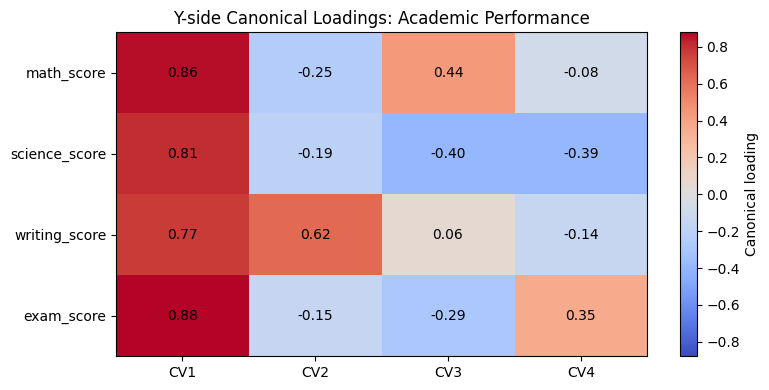

In [17]:
plot_loading_heatmap(
    y_loadings,
    "Y-side Canonical Loadings: Academic Performance",
)

## 17. Canonical Coefficients / 正準係数

The model also provides the coefficients used to construct the canonical variates.

Because all variables were standardized, the coefficients are more comparable than they would be on their original scales. Still, canonical loadings are usually easier to interpret.

モデルが求めた正準係数も確認できます。

今回は標準化済みなので元の尺度のままより比較しやすいですが、解釈には正準負荷量も併せて使います。

In [18]:
x_coefficients = pd.DataFrame(
    cca.x_weights_,
    index=x_features,
    columns=[f"CV{i+1}" for i in range(n_components)],
)

y_coefficients = pd.DataFrame(
    cca.y_weights_,
    index=y_features,
    columns=[f"CV{i+1}" for i in range(n_components)],
)

print("X-side canonical coefficients")
display(x_coefficients.round(3))

print("Y-side canonical coefficients")
display(y_coefficients.round(3))

X-side canonical coefficients


,CV1,CV2,CV3,CV4
study_hours_week,0.694,-0.306,-0.302,-0.578
attendance_rate,0.517,0.379,-0.421,0.642
assignment_completion_rate,0.180,0.826,0.350,-0.403
practice_sessions_week,0.467,-0.284,0.780,0.304


Y-side canonical coefficients


,CV1,CV2,CV3,CV4
math_score,0.583,-0.437,0.670,-0.141
science_score,0.266,-0.298,-0.576,-0.713
writing_score,0.461,0.844,0.094,-0.257
exam_score,0.613,-0.090,-0.459,0.637


## 18. What Does the First Canonical Relationship Mean? / 第1正準関係は何を意味するか

Interpretation should combine:

1. the size of the canonical correlation,
2. the X-side canonical loadings,
3. the Y-side canonical loadings.

For example, if study hours, attendance, assignment completion, and practice sessions all load strongly on the first X canonical variate, it can be interpreted as an **overall learning-engagement dimension**.

If mathematics, science, writing, and examination scores all load strongly on the first Y canonical variate, it can be interpreted as an **overall academic-performance dimension**.

A strong first canonical correlation would then suggest that students with stronger overall learning behavior also tend to show stronger overall academic performance.

解釈では、正準相関係数の大きさ、X側の負荷量、Y側の負荷量を組み合わせて考えます。

たとえばX側の各学習行動変数が第1正準変量に強く負荷していれば「総合的な学習活動」、Y側の各成績変数が強く負荷していれば「総合的な学業成績」と解釈できます。

その2つの第1正準変量に強い相関があれば、「総合的に学習行動が活発な学生ほど、総合的な学業成績も高い傾向がある」と考えられます。

## 19. Assumptions and Limitations / 前提条件と限界

Important considerations include:

- Relationships are primarily linear.
- Observations should be independent.
- Strong multicollinearity can make canonical coefficients unstable.
- CCA can overfit when the sample size is small relative to the number of variables.
- Outliers may strongly affect correlations.
- Classical statistical inference for CCA often assumes multivariate normality.
- A strong canonical correlation does not prove causation.
- The dataset used here is simulated for educational purposes.

主な注意点は次のとおりです。

- 主として線形関係を扱う。
- 観測値が独立していることが望ましい。
- 強い多重共線性があると正準係数が不安定になることがある。
- 変数数に対してサンプル数が少ないと過学習しやすい。
- 外れ値が相関に大きく影響する可能性がある。
- 古典的な統計的推論では多変量正規性を仮定することがある。
- 強い正準相関があっても因果関係を意味しない。
- 今回は学習用のシミュレーションデータである。

## 20. Conclusion / まとめ

This Notebook used Canonical Correlation Analysis to examine the relationship between two multivariate sets:

**Learning Behavior (X)**

and

**Academic Performance (Y)**

The workflow was:

1. Define two meaningful variable sets
2. Inspect ordinary cross-correlations
3. Standardize variables
4. Fit CCA
5. Calculate canonical correlations
6. Visualize canonical variates
7. Calculate and interpret canonical loadings
8. Examine canonical coefficients
9. Interpret the relationship between the two variable sets

CCA is especially useful when the research question is not about one explanatory variable and one target variable, but about the relationship between **two groups of variables as a whole**.

このNotebookでは、「学習行動」と「学業成績」という2つの多変量な変数群の関係を正準相関分析で分析しました。

正準相関分析は、「1つの目的変数を予測する」という問題ではなく、**2つの変数群全体がどのように関連しているのか**を捉えたい場合に有効な手法です。